# Helmholtz 2D normalizada - PINN-SIREN con campo complejo y LHS
### Proyecto: Simulación Acelerada de Speckle Óptico
**Roberto Hernández Estrada** | Maestría en Ciencias de la Computación - UJAT
**Director:** Dr. José Adán Hernández Nolasco

Este notebook presenta la versión didáctica y normalizada de la validación NB02. Conserva la arquitectura, los datos y el entrenamiento de la corrida validada. Las salidas visibles corresponden a esa ejecución y pueden regenerarse con las etiquetas y métricas ampliadas.

## Objetivo

Validar que una PINN-SIREN aproxima campos complejos que satisfacen la ecuación homogénea de Helmholtz en dos coordenadas espaciales normalizadas. La referencia principal es una onda plana analítica y la extensión final comprueba las cuatro combinaciones de signos de un vector con $|\widetilde{k}_x|=|\widetilde{k}_y|=\widetilde{k}/\sqrt{2}$. Este notebook valida el bloque matemático 2D previo a la simulación de speckle.

$$\frac{\partial^2 E}{\partial \tilde{x}^2}+\frac{\partial^2 E}{\partial \tilde{y}^2}+\tilde{k}^{2}E=0,\qquad (\tilde{x},\tilde{y})\in[0,1]^2$$

$$E(\tilde{x},\tilde{y})=E_{\mathrm{real}}(\tilde{x},\tilde{y})+iE_{\mathrm{imag}}(\tilde{x},\tilde{y}).$$

### Convención de notación

| Símbolo físico/matemático | Nombre breve en el código | Significado |
|---|---|---|
| $x_{\mathrm{físico}},y_{\mathrm{físico}}$ | — | Coordenadas dimensionales en metros |
| $\tilde{x}=x_{\mathrm{físico}}/\lambda$, $\tilde{y}=y_{\mathrm{físico}}/\lambda$ | `x`, `y` | Coordenadas normalizadas |
| $\tilde{k}=k_{\mathrm{real}}\lambda=2\pi$ | `k` | Número de onda adimensional |
| $w_f$ | `physics_weight` | Peso numérico de la pérdida física; no es la longitud de onda |
| $\omega_0$ | `omega_0` | Frecuencia interna de las activaciones SIREN; no es la frecuencia óptica $\omega$ |

Así, $[0,1]^2$ representa un cuadrado físico de una longitud de onda por lado: $[0,\lambda]\times[0,\lambda]$. Para $\lambda=638$ nm, el lado equivale a $0.638\,\mu$m.

## Configuración seleccionada frente a la corrida base

| Hiperparámetro | Corrida base | Esta corrida | Observación |
|---|---|---|---|
| `hidden_dim` | 64 | **128** | Se modificó junto con otros hiperparámetros; no hay atribución causal aislada |
| `N_colloc` | 2,000 | **3,000** | Mayor densidad de evaluación física por LHS |
| `N_boundary_per_edge` | 200 | **300** | Mayor densidad de datos por borde |
| `patience` | 500 | **800** | Adam explora más antes de entregar a L-BFGS |
| `lbfgs max_iter` | 500 | **1,000** | L-BFGS con más margen de ajuste fino |
| `lbfgs history_size` | 50 | **100** | Mejor aproximación de curvatura |

**Resultado histórico de la corrida base:** promedio aritmético de errores L2 por componente = 0.436%.  
**Resultado histórico de esta corrida:** promedio aritmético = 0.171% (real: 0.214%; imaginaria: 0.127%). Más adelante se añade también la norma L2 conjunta del campo complejo, que es la métrica rigurosa para $E$.

> **Alcance:** una onda plana tiene $|E|=1$ e intensidad uniforme. Por tanto, este resultado no constituye todavía una simulación de speckle ni demuestra propagación a múltiples distancias.

## 0. Imports y configuración del entorno

In [1]:
import sys
from pathlib import Path

# Resolver la raíz sin depender de si Jupyter inició en la raíz o en notebooks/.
_cwd = Path.cwd().resolve()
PROJECT_ROOT = _cwd.parent if _cwd.name == 'notebooks' else _cwd
if not (PROJECT_ROOT / 'src').is_dir():
    raise RuntimeError(f'No se encontró src/ desde el directorio de trabajo: {_cwd}')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
from scipy.stats import qmc, pearsonr

# ── Importar desde src/ ───────────────────────────────────────────────────────
from src.models import PINN_2D_SIREN
from src.losses import pinn_loss_2d, helmholtz_residual_2d
from src.utils  import get_figures_dir, save_model, l2_rel

# ── Semilla global - SIEMPRE al inicio para reproducibilidad ──────────────────
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Dispositivo ───────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo     : {device}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'VRAM total      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'Semilla fijada  : {SEED}')
print()
print('Entorno listo y reproducible.')

# ── Warm-up CUDA - activa contexto GPU antes del primer backward ─────────────
if torch.cuda.is_available():
    _ = torch.zeros(1, device=device)
    torch.cuda.synchronize()
    print(' Contexto CUDA inicializado.')


Dispositivo     : cuda
GPU             : NVIDIA GeForce RTX 5050 Laptop GPU
VRAM total      : 8.5 GB
Semilla fijada  : 42

Entorno listo y reproducible.
 Contexto CUDA inicializado.


---
## 1. De la ecuación física a la ecuación normalizada

En un medio homogéneo y sin fuentes, la ecuación escalar de Helmholtz para el fasor complejo es

$$\frac{\partial^2 E}{\partial x_{\mathrm{físico}}^2}+\frac{\partial^2 E}{\partial y_{\mathrm{físico}}^2}+k_{\mathrm{real}}^2E=0,\qquad k_{\mathrm{real}}=\frac{2\pi}{\lambda}. $$

Definimos $\tilde{x}=x_{\mathrm{físico}}/\lambda$ y $\tilde{y}=y_{\mathrm{físico}}/\lambda$. Por la regla de la cadena,

$$\frac{\partial^2 E}{\partial x_{\mathrm{físico}}^2}=\frac{1}{\lambda^2}\frac{\partial^2 E}{\partial \tilde{x}^2},\qquad \frac{\partial^2 E}{\partial y_{\mathrm{físico}}^2}=\frac{1}{\lambda^2}\frac{\partial^2 E}{\partial \tilde{y}^2}. $$

Al sustituir y multiplicar por $\lambda^2$ se obtiene

$$\boxed{\frac{\partial^2 E}{\partial \tilde{x}^2}+\frac{\partial^2 E}{\partial \tilde{y}^2}+\tilde{k}^{2}E=0},\qquad \tilde{k}=k_{\mathrm{real}}\lambda=2\pi. $$

En el código se escriben `x`, `y` y `k` para abreviar $\tilde{x}$, $\tilde{y}$ y $\tilde{k}$; todas las derivadas que calcula `autograd` son respecto de coordenadas normalizadas.

### Solución analítica usada para validar

Se elige una onda plana compleja

$$E_{\mathrm{ref}}(\tilde{x},\tilde{y})=e^{i(\tilde{k}_x\tilde{x}+\tilde{k}_y\tilde{y})}. $$

Si $\Phi=\tilde{k}_x\tilde{x}+\tilde{k}_y\tilde{y}$, entonces $\partial^2E/\partial\tilde{x}^2=-\tilde{k}_x^2E$ y $\partial^2E/\partial\tilde{y}^2=-\tilde{k}_y^2E$. Al sustituir en Helmholtz queda

$$(-\tilde{k}_x^2-\tilde{k}_y^2+\tilde{k}^2)E=0. $$

Por ello debe cumplirse la relación de dispersión $\tilde{k}_x^2+\tilde{k}_y^2=\tilde{k}^2$. La elección simétrica

$$\tilde{k}_x=\tilde{k}_y=\frac{\tilde{k}}{\sqrt{2}}=\pi\sqrt{2}$$

describe propagación en la dirección $(1,1)/\sqrt{2}$, es decir, a $45^\circ$ respecto del eje $\tilde{x}$. Por Euler,

$$E_{\mathrm{real}}=\cos\Phi,\qquad E_{\mathrm{imag}}=\sin\Phi,\qquad |E|^2=1. $$

> **Nota para NB02:** las trazas de estas dos expresiones sobre $\partial[0,1]^2$ proporcionan las condiciones de frontera. En todo el dominio constituyen una solución exacta manufacturada, independiente del proceso de optimización de la PINN.

### ¿Por qué dos salidas?

El campo eléctrico óptico es una cantidad **compleja**:

$$E(x,y) = E_{\text{real}}(x,y) + i \cdot E_{\text{imag}}(x,y)$$

La implementación de PyTorch usa parámetros reales. Por eso representamos el campo complejo mediante **una red con dos canales de salida**, uno por componente.

Ambas partes satisfacen la ecuación de Helmholtz de forma independiente:

$$\tilde{\nabla}^2 E_{\text{real}} + \tilde{k}^2 E_{\text{real}} = 0$$
$$\tilde{\nabla}^2 E_{\text{imag}} + \tilde{k}^2 E_{\text{imag}} = 0$$

La intensidad asociada al campo se obtiene después:

$$I(x,y) = |E|^2 = E_{\text{real}}^2 + E_{\text{imag}}^2$$

### ¿Por qué SIREN y no tanh?

Como en NB01, las activaciones sinusoidales son adecuadas para representar funciones oscilatorias y su inicialización está diseñada para mantener señales y derivadas útiles a través de las capas. Esto no garantiza por sí solo la convergencia: también influyen el muestreo, la ponderación de pérdidas y los optimizadores.

> **Cuidado con los símbolos:** el peso `physics_weight=0.1` es un hiperparámetro numérico. No debe confundirse con la longitud de onda óptica $\lambda$ ni con $\omega_0$ de SIREN.

In [2]:
# Sine y PINN_2D_SIREN importados desde src/models.py
# Ver src/models.py para la implementacion completa (Sitzmann et al., 2020)

# ── Vista previa de la arquitectura ───────────────────────────────────────────
torch.manual_seed(SEED)
_preview = PINN_2D_SIREN(hidden_dim=128, num_layers=5, omega_0=1.0)
print('Arquitectura PINN_2D_SIREN (config definitiva - hidden_dim=128):')
print(_preview)
print(f'\nTotal de parametros : {sum(p.numel() for p in _preview.parameters()):,}')
print(f'Activacion          : sin(ω₀·x) con ω₀=1.0')
print(f'Inicializacion      : Sitzmann et al. (2020)')
del _preview


Arquitectura PINN_2D_SIREN (config definitiva - hidden_dim=128):
PINN_2D_SIREN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): Sine()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Sine()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Sine()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Sine()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): Sine()
    (10): Linear(in_features=128, out_features=2, bias=True)
  )
)

Total de parametros : 66,690
Activacion          : sin(ω₀·x) con ω₀=1.0
Inicializacion      : Sitzmann et al. (2020)


---
## 2. Arquitectura de la red - PINN 2D SIREN

La red recibe $(\tilde{x},\tilde{y})$ y predice $(E_{\mathrm{real}},E_{\mathrm{imag}})$. Conserva el esquema SIREN de NB01, pero amplía la entrada y la salida a dos componentes.

---
## 3. Muestreo LHS - Latin Hypercube Sampling

En 1D, NB01 usa puntos sobre una línea. En 2D se emplean 3,000 puntos de colocación mediante **Latin Hypercube Sampling (LHS)**. Una PINN es *mesh-free* en el sentido de que no necesita elementos ni conectividad entre nodos; sí necesita puntos donde evaluar el residuo y una malla separada para visualizar el resultado.

### ¿Por qué LHS?

Con una malla uniforme de $N \times N$ puntos en 2D, el número de puntos crece cuadráticamente.
Para $N=45$ ya son 2,025 puntos. Una malla cartesiana es regular; LHS permite fijar directamente el total de muestras y estratifica cada coordenada.

LHS favorece una cobertura estratificada de las proyecciones del dominio con un número fijo de puntos:

| Muestreo | Ejemplo cercano a 3,000 puntos en $[0,1]^2$ | Cobertura | Observación |
|---|---|---|---|
| Malla uniforme | $55\times55=3,025$ | Regular | Incluye estructura cartesiana |
| Aleatorio puro | 3,000 | Irregular | Puede producir agrupamientos |
| **LHS** | **3,000** | **Estratificada por dimensión** | No exige conectividad |

LHS divide cada dimensión en $N$ estratos iguales y coloca exactamente un punto en cada estrato,
reduciendo agrupamientos en cada dimensión. Este notebook no contiene una ablación LHS contra malla uniforme, por lo que no se afirma superioridad cuantitativa entre ambos métodos.

---
## 4. Configuración del experimento

Todos los hiperparámetros en un solo lugar.
Arquitectura basada en el mismo esquema SIREN de NB01; los pesos no se heredan. El modelo se inicializa desde cero porque cambian las dimensiones de entrada, salida y capas ocultas.

### Parámetros de la referencia analítica

Para validar la PINN necesitamos una solución exacta conocida.
Usamos una onda plana que satisface Helmholtz 2D exactamente:

$$E_{\text{real}}(\tilde{x},\tilde{y}) = \cos(\tilde{k}_x\tilde{x} + \tilde{k}_y\tilde{y}), \quad E_{\text{imag}}(\tilde{x},\tilde{y}) = \sin(\tilde{k}_x\tilde{x} + \tilde{k}_y\tilde{y})$$

con $\tilde{k}_x^2 + \tilde{k}_y^2 = \tilde{k}^2 = (2\pi)^2$.

La elección más simple y simétrica:

$$\tilde{k}_x = \tilde{k}_y = \frac{\tilde{k}}{\sqrt{2}} = \frac{2\pi}{\sqrt{2}} = \pi\sqrt{2}$$

**Verificación:** $\tilde{k}_x^2 + \tilde{k}_y^2 = 2\pi^2 + 2\pi^2 = 4\pi^2 = \tilde{k}^2$. En el código, los nombres breves son `k_x`, `k_y` y `k`.

In [3]:
# ── Hiperparámetros ────────────────────────────────────────────────────────────
CONFIG = {
    # ── Láser simulado (documentación) ────────────────────────────────────────
    'lambda_laser' : 638e-9,      # diodo rojo λ = 638 nm (computacional)
    'L'            : 1,           # dominio = 1×1 longitudes de onda

    # ── Física adimensional ────────────────────────────────────────────────────
    'k'            : 2 * np.pi,   # k̃ adimensional - siempre 2π

    # ── Puntos de colocación (LHS) ─────────────────────────────────────────────
    'N_colloc'     : 3000,        # ← AUMENTADO: era 2000 - mejor cobertura [0,1]²
    'N_boundary_per_edge': 300,   # puntos por cada uno de los cuatro bordes

    # ── Arquitectura SIREN ─────────────────────────────────────────────────────
    'hidden_dim'   : 128,         # configuración seleccionada en la corrida validada
    'num_layers'   : 5,           # sin cambio - validado en NB01
    'omega_0'      : 1.0,         # sin cambio - calibrado para k=2π

    # ── Entrenamiento ──────────────────────────────────────────────────────────
    'n_epochs'     : 15000,       # sin cambio
    'lr'           : 1e-3,        # sin cambio - funciona bien sin scheduler
    'physics_weight': 0.1,        # w_f: peso numérico de la suma de residuos real+imag
    'patience'     : 800,         # ← AUMENTADO: era 500 - Adam explora más

    # ── L-BFGS ────────────────────────────────────────────────────────────────
    'lbfgs_max_iter' : 1000,      # ← AUMENTADO: era 500 - L-BFGS con más margen
    'lbfgs_history'  : 100,       # ← AUMENTADO: era 50  - mejor aprox. de curvatura

    # ── Reproducibilidad ───────────────────────────────────────────────────────
    'seed'         : SEED,

    # ── Meta de la tesis ───────────────────────────────────────────────────────
    'l2_threshold' : 0.05,
}

print('Configuración del experimento - VERSIÓN OPTIMIZADA:')
print('-' * 50)
ORIGINAL = {'N_colloc':2000,'N_boundary_per_edge':200,'hidden_dim':64,'patience':500}
for key, val in CONFIG.items():
    marker = '  ← CAMBIADO' if key in ORIGINAL and ORIGINAL[key] != val else ''
    if key in ('lbfgs_max_iter','lbfgs_history'): marker = '  ← NUEVO'
    print(f'  {key:<18} : {val}{marker}')
print('-' * 50)

k   = CONFIG['k']
k_x = k / np.sqrt(2)
k_y = k / np.sqrt(2)
print(f'  k_x = k/√2       : {k_x:.4f}')
print(f'  k_y = k/√2       : {k_y:.4f}')
print(f'  Verificación k²  : {k_x**2 + k_y**2:.4f} = k² = {k**2:.4f} ')
print()
print('Cambios frente a la corrida base:')
def count_parameters_2d(width, num_layers):
    return (2 + 1) * width + (num_layers - 1) * (width + 1) * width + (width + 1) * 2

base_params = count_parameters_2d(64, CONFIG['num_layers'])
current_params = count_parameters_2d(CONFIG['hidden_dim'], CONFIG['num_layers'])
print(f'  hidden_dim  : 64  → 128  (+{128-64} neuronas - parámetros: {base_params:,} → {current_params:,})')
print(f'  N_colloc    : 2000 → 3000 (+1000 puntos LHS)')
print(f'  frontera    : 200  → 300 puntos por borde (+400 filas en total)')
print(f'  patience    : 500  → 800  (+300 épocas de exploración)')
print(f'  lbfgs iter  : 500  → 1000 (+500 iter ajuste fino)')
print()
lam = CONFIG['lambda_laser']
L   = CONFIG['L']
print('Láser simulado:')
print(f'  lambda_laser        : {lam * 1e9:.0f} nm')
print(f'  k adimensional      : 2π = {k:.4f}')
print(f'  k real equivalente  : {2 * np.pi / lam:.3e} m⁻¹')
print(f'  Dominio simulado    : {L}×{L} longitudes de onda')
print(f'  Equivale físicamente: {L * lam * 1e6:.4f} × {L * lam * 1e6:.4f} μm²')

Configuración del experimento - VERSIÓN OPTIMIZADA:
--------------------------------------------------
  lambda_laser       : 6.38e-07
  L                  : 1
  k                  : 6.283185307179586
  N_colloc           : 3000  ← CAMBIADO
  N_boundary_per_edge : 300  ← CAMBIADO
  hidden_dim         : 128  ← CAMBIADO
  num_layers         : 5
  omega_0            : 1.0
  n_epochs           : 15000
  lr                 : 0.001
  physics_weight     : 0.1
  patience           : 800  ← CAMBIADO
  lbfgs_max_iter     : 1000  ← NUEVO
  lbfgs_history      : 100  ← NUEVO
  seed               : 42
  l2_threshold       : 0.05
--------------------------------------------------
  k_x = k/√2       : 4.4429
  k_y = k/√2       : 4.4429
  Verificación k²  : 39.4784 = k² = 39.4784 

Cambios frente a la corrida base:
  hidden_dim  : 64  → 128  (+64 neuronas - parámetros: 16,962 → 66,690)
  N_colloc    : 2000 → 3000 (+1000 puntos LHS)
  frontera    : 200  → 300 puntos por borde (+400 filas en total)
  pat

---
## 5. Preparar datos de entrenamiento

### Puntos de colocación: LHS en el interior

Los 3,000 puntos LHS no son mediciones experimentales: son coordenadas donde `autograd` evalúa si la salida de la red satisface la ecuación diferencial.

### Condiciones de frontera: cuatro bordes de $[0,1]^2$

Se prescriben los valores analíticos de $E_{\mathrm{real}}$ y $E_{\mathrm{imag}}$ en los cuatro bordes. Con 300 puntos por borde se generan 1,200 filas. Las cuatro esquinas aparecen dos veces, de modo que existen 1,196 coordenadas únicas; se conserva esta construcción para reproducir exactamente la corrida validada.

### La función de pérdida PINN 2D

$$\mathcal{L}_{\mathrm{total}} = \mathcal{L}_{\mathrm{frontera}} + w_f \left(\mathcal{L}_{\mathrm{física,real}} + \mathcal{L}_{\mathrm{física,imag}}\right)$$

| Término | Qué mide | Dónde |
|---|---|---|
| $\mathcal{L}_{\mathrm{frontera}}$ | Error cuadrático de ambos canales en los 4 bordes | 1,200 filas; 1,196 coordenadas únicas |
| $\mathcal{L}_{\text{física,real}}$ | Residuo Helmholtz de E_real | 3000 puntos LHS |
| $\mathcal{L}_{\text{física,imag}}$ | Residuo Helmholtz de E_imag | 3000 puntos LHS |

> **$w_f=0.1$** es la ponderación numérica usada en la corrida validada. La implementación suma las MSE de los residuos real e imaginario; por eso su escala conjunta debe equilibrarse con la pérdida de frontera. Es un hiperparámetro empírico, no una constante física.

In [4]:
k   = CONFIG['k']
k_x = k / np.sqrt(2)
k_y = k / np.sqrt(2)

# ── Puntos interiores con LHS ──────────────────────────────────────────────────
sampler   = qmc.LatinHypercube(d=2, seed=CONFIG['seed'])
lhs_pts   = sampler.random(n=CONFIG['N_colloc'])
xy_colloc = torch.tensor(lhs_pts, dtype=torch.float32).to(device)

print(f'Puntos de colocación (LHS): {xy_colloc.shape}  → {CONFIG["N_colloc"]} puntos en [0,1]²')

# ── Condiciones de frontera - 4 bordes ────────────────────────────────────────
N_b  = CONFIG['N_boundary_per_edge']
t    = np.linspace(0, 1, N_b)

x_bot = np.stack([t,             np.zeros(N_b)], axis=1)
x_top = np.stack([t,             np.ones(N_b)],  axis=1)
x_lft = np.stack([np.zeros(N_b), t],             axis=1)
x_rgt = np.stack([np.ones(N_b),  t],             axis=1)

xy_boundary_np = np.vstack([x_bot, x_top, x_lft, x_rgt])

phase_boundary     = k_x * xy_boundary_np[:, 0] + k_y * xy_boundary_np[:, 1]
E_real_boundary_np = np.cos(phase_boundary)
E_imag_boundary_np = np.sin(phase_boundary)
E_boundary_np      = np.stack([E_real_boundary_np, E_imag_boundary_np], axis=1)

xy_boundary = torch.tensor(xy_boundary_np, dtype=torch.float32).to(device)
E_boundary  = torch.tensor(E_boundary_np,  dtype=torch.float32).to(device)

n_boundary_unique = np.unique(xy_boundary_np, axis=0).shape[0]
print(f'Filas de frontera          : {xy_boundary.shape}  → {4*N_b} ({N_b} por borde)')
print(f'Coordenadas únicas         : {n_boundary_unique} (las 4 esquinas se repiten)')
print(f'  Borde inferior (y=0)     : {N_b} puntos')
print(f'  Borde superior (y=1)     : {N_b} puntos')
print(f'  Borde izquierdo (x=0)    : {N_b} puntos')
print(f'  Borde derecho (x=1)      : {N_b} puntos')
print()
print('Muestra de condiciones de frontera:')
print(f'  E(0,0)   real={E_real_boundary_np[0]:.4f}   imag={E_imag_boundary_np[0]:.4f}')
print(f'  E(0.5,0) real={np.cos(k_x*0.5):.4f}   imag={np.sin(k_x*0.5):.4f}')
print(f'  E(1,1)   real={np.cos(k_x+k_y):.4f}   imag={np.sin(k_x+k_y):.4f}')

Puntos de colocación (LHS): torch.Size([3000, 2])  → 3000 puntos en [0,1]²
Filas de frontera          : torch.Size([1200, 2])  → 1200 (300 por borde)
Coordenadas únicas         : 1196 (las 4 esquinas se repiten)
  Borde inferior (y=0)     : 300 puntos
  Borde superior (y=1)     : 300 puntos
  Borde izquierdo (x=0)    : 300 puntos
  Borde derecho (x=1)      : 300 puntos

Muestra de condiciones de frontera:
  E(0,0)   real=1.0000   imag=0.0000
  E(0.5,0) real=-0.6057   imag=0.7957
  E(1,1)   real=-0.8582   imag=0.5133


---
## 6. Funciones auxiliares - derivadas y residuo de Helmholtz 2D

Estas funciones calculan las derivadas de la red usando **autograd** y evalúan
qué tanto viola la ecuación de Helmholtz normalizada en cada punto del dominio $[0,1]^2$.

### ¿Qué cambia respecto a 1D?

En 1D el residuo era una sola derivada de segundo orden:

$$R(\tilde{x}) = \frac{d^2E}{d\tilde{x}^2} + \tilde{k}^2 E$$

En 2D el residuo involucra el **laplaciano** - derivadas parciales en ambas dimensiones simultáneamente:

$$R(\tilde{x},\tilde{y}) = \frac{\partial^2 E}{\partial \tilde{x}^2} + \frac{\partial^2 E}{\partial \tilde{y}^2} + \tilde{k}^2 E = \tilde{\nabla}^2 E + \tilde{k}^2 E$$

Y como el campo es complejo, se evalúa para **ambas partes por separado**:

$$R_{\text{real}}(\tilde{x},\tilde{y}) = \tilde{\nabla}^2 E_{\text{real}} + \tilde{k}^2 E_{\text{real}} = 0$$
$$R_{\text{imag}}(\tilde{x},\tilde{y}) = \tilde{\nabla}^2 E_{\text{imag}} + \tilde{k}^2 E_{\text{imag}} = 0$$

### ¿Cómo calcula autograd el laplaciano en 2D?

El mismo principio que en 1D - PyTorch construye el grafo computacional y lo recorre
al revés - pero ahora en **dos pasos por dimensión**:

```
forward:  (x,y) → operaciones → E_real, E_imag     (PyTorch registra todo)

backward paso 1:  E → ∂E/∂x,  ∂E/∂y               (gradiente espacial - vector 2D)
backward paso 2:  ∂E/∂x → ∂²E/∂x²                 (segunda derivada en x)
                  ∂E/∂y → ∂²E/∂y²                 (segunda derivada en y)

laplaciano:  ∂²E/∂x² + ∂²E/∂y²
```

> **Clave:** el tensor de entrada es `(N, 2)` con columnas `[x, y]`.
> PyTorch calcula los gradientes respecto a **cada columna por separado**,
> por eso `grad_f[:, 0]` es la derivada en x y `grad_f[:, 1]` en y.
> Ambas con `requires_grad=True` desde el inicio del forward.

| Situación | R_real | R_imag |
|---|---|---|
| Red perfecta | 0 en todo [0,1]² | 0 en todo [0,1]² |
| Red sin entrenar | Valores grandes | Valores grandes |
| Durante entrenamiento | Se intenta minimizar | Se intenta minimizar |

> Una pérdida pequeña en los puntos LHS es necesaria, pero la validación final también evalúa el residuo en una malla distinta de $100\times100$ puntos.

In [5]:
# helmholtz_residual_2d y pinn_loss_2d importados desde src/losses.py
# Ver src/losses.py para la implementacion completa

print('Funciones auxiliares 2D cargadas desde src/losses.py')
print('   helmholtz_residual_2d() - ∇²E_real + k²E_real  y  ∇²E_imag + k²E_imag')
print('   pinn_loss_2d()          - L_total = L_datos + λ·(L_real + L_imag)')


Funciones auxiliares 2D cargadas desde src/losses.py
   helmholtz_residual_2d() - ∇²E_real + k²E_real  y  ∇²E_imag + k²E_imag
   pinn_loss_2d()          - L_total = L_datos + λ·(L_real + L_imag)


---
## 7. Entrenamiento - Adam + early stopping por paciencia + L-BFGS

### Estrategia de entrenamiento

La misma estrategia de la corrida base, con ajustes conjuntos de hiperparámetros:

| Fase | Optimizador | Rol | Config |
|---|---|---|---|
| 1 | Adam | Optimización inicial | lr=1e-3, máx 15,000 épocas |
| - | Early stopping por **paciencia** | Para si no hay mejora en 800 épocas | era 500 |
| 2 | L-BFGS | Ajuste fino de alta precisión | max_iter=1000, history=100 |

> **¿Por qué patience=800?**
> En la corrida base Adam paró cerca de la época 14,000 (de 15,000 máx).
> Con 800 épocas de paciencia Adam puede continuar mientras la pérdida siga
> mejorando; no se interpreta como una garantía de escapar de mínimos locales.

> **¿Por qué L-BFGS con max_iter=1000?**
> En la corrida base L-BFGS registró 526 evaluaciones en 17.8 s
> y llegó al límite de 500. Con 1,000 tiene margen para profundizar
> más desde el punto de partida que entrega Adam.

> **Distinción importante:** `max_iter` limita las iteraciones internas del optimizador. El contador implementado dentro de `closure()` registra evaluaciones de la función objetivo. La búsqueda de línea puede evaluar `closure()` más de una vez por iteración, por lo que 1,035 evaluaciones con `max_iter=1,000` no representan una violación del límite.

In [6]:
# ── Semilla antes de instanciar ───────────────────────────────────────────────
torch.manual_seed(CONFIG['seed'])
torch.cuda.manual_seed(CONFIG['seed'])

# ── Modelo SIREN 2D ───────────────────────────────────────────────────────────
model_2d = PINN_2D_SIREN(
    hidden_dim = CONFIG['hidden_dim'],
    num_layers = CONFIG['num_layers'],
    omega_0    = CONFIG['omega_0']
).to(device)

n_params = sum(p.numel() for p in model_2d.parameters())
print(f'Modelo: PINN_2D_SIREN | {CONFIG["num_layers"]} capas × {CONFIG["hidden_dim"]} | '
      f'ω₀={CONFIG["omega_0"]} | {n_params:,} parámetros')

optimizer = torch.optim.Adam(model_2d.parameters(), lr=CONFIG['lr'])

# ── Variables de entrenamiento ─────────────────────────────────────────────────
history    = {'total': [], 'data': [], 'physics': []}
PATIENCE   = CONFIG['patience']
MIN_DELTA  = 1e-7
best_loss  = float('inf')
best_state = None
sin_mejora = 0

print(f'\nEntrenando PINN 2D...')
print(f'  k̃={k:.4f} | LHS {CONFIG["N_colloc"]} pts | {4*CONFIG["N_boundary_per_edge"]} filas de frontera')
print(f'  Épocas máx: {CONFIG["n_epochs"]} | lr={CONFIG["lr"]} | w_f={CONFIG["physics_weight"]}')
print(f'  Early stopping: paciencia = {PATIENCE} épocas sin mejora')
print(f'  Arquitectura  : SIREN ω₀={CONFIG["omega_0"]} | {n_params:,} parámetros')
print()

epoch_final = CONFIG['n_epochs']
t0_adam     = time.time()

for epoch in range(CONFIG['n_epochs']):
    optimizer.zero_grad()

    loss, loss_data, loss_physics = pinn_loss_2d(
        model_2d, xy_colloc, xy_boundary, E_boundary,
        k           = CONFIG['k'],
        lambda_phys = CONFIG['physics_weight']
    )

    loss.backward()
    optimizer.step()

    current_loss = loss.item()
    history['total'].append(current_loss)
    history['data'].append(loss_data.item())
    history['physics'].append(loss_physics.item())

    # ── Paciencia + rastreo del mejor ─────────────────────────────────────────
    if current_loss < best_loss - MIN_DELTA:
        best_loss  = current_loss
        best_state = {k_: v.clone() for k_, v in model_2d.state_dict().items()}
        sin_mejora = 0
    else:
        sin_mejora += 1

    # ── Reporte cada 1000 épocas - mismo formato que NB01 ──────────────────────
    if (epoch + 1) % 1000 == 0:
        elapsed = time.time() - t0_adam
        print(f'  Época {epoch+1:5d} | '
              f'L_total: {current_loss:.3e} | '
              f'L_datos: {loss_data.item():.3e} | '
              f'L_física: {loss_physics.item():.3e} | '
              f'Mejor: {best_loss:.3e} | '
              f'Sin mejora: {sin_mejora} | '
              f'Tiempo: {elapsed:.1f} s')

    # ── Early stopping ─────────────────────────────────────────────────────────
    if sin_mejora >= PATIENCE:
        epoch_final = epoch + 1
        print(f'\n  ⏹ Early stopping por paciencia en época {epoch_final}')
        print(f'  Se detiene Adam; el mejor estado se restaurará antes de L-BFGS (loss={best_loss:.3e})')
        break

# Restaurar siempre el mejor estado de Adam, incluso si se alcanza n_epochs.
if best_state is not None:
    model_2d.load_state_dict(best_state)

t1_adam     = time.time()
tiempo_adam = t1_adam - t0_adam
print(f'\nAdam completado en {epoch_final} épocas '
      f'(máximo configurado: {CONFIG["n_epochs"]})')
print(f'  Mejor L_total alcanzado : {best_loss:.3e}')
print(f'  Tiempo Adam             : {tiempo_adam:.1f} s')

# ── Ajuste fino con L-BFGS ────────────────────────────────────────────────────
print('\nAjuste fino con L-BFGS...')
print(f'  max_iter={CONFIG["lbfgs_max_iter"]} | history_size={CONFIG["lbfgs_history"]} | line_search=strong_wolfe')
print()

optimizer_lbfgs = torch.optim.LBFGS(
    model_2d.parameters(),
    lr             = 1.0,
    max_iter       = CONFIG['lbfgs_max_iter'],
    history_size   = CONFIG['lbfgs_history'],
    line_search_fn = 'strong_wolfe'
)

history_lbfgs = {'total': [], 'data': [], 'physics': []}
closure_eval_count = [0]
t0_lbfgs      = time.time()

def closure():
    optimizer_lbfgs.zero_grad()
    loss, loss_data, loss_physics = pinn_loss_2d(
        model_2d, xy_colloc, xy_boundary, E_boundary,
        k           = CONFIG['k'],
        lambda_phys = CONFIG['physics_weight']
    )
    loss.backward()
    history_lbfgs['total'].append(loss.item())
    history_lbfgs['data'].append(loss_data.item())
    history_lbfgs['physics'].append(loss_physics.item())
    closure_eval_count[0] += 1
    if closure_eval_count[0] % 100 == 0:
        print(f'  Eval. closure {closure_eval_count[0]:4d} | '
              f'L_total: {loss.item():.3e} | '
              f'L_datos: {loss_data.item():.3e} | '
              f'L_física: {loss_physics.item():.3e}')
    return loss

optimizer_lbfgs.step(closure)
t1_lbfgs      = time.time()
tiempo_lbfgs  = t1_lbfgs - t0_lbfgs

print('\nAjuste fino L-BFGS completado.')
print(f'  Tiempo L-BFGS : {tiempo_lbfgs:.1f} s')

# ── Resumen del entrenamiento - mismo formato que NB01 ────────────────────────
print(f'\nResumen del entrenamiento:')
print(f'  Épocas Adam         : {epoch_final} / {CONFIG["n_epochs"]}')
print(f'  Early stopping      : por paciencia ({PATIENCE} épocas sin mejora)')
print(f'  Mejor L_total (Adam): {best_loss:.3e}')
print(f'  Tiempo Adam         : {tiempo_adam:.1f} s')
print(f'  Máximo de iteraciones L-BFGS : {CONFIG["lbfgs_max_iter"]}')
print(f'  Evaluaciones de closure      : {closure_eval_count[0]}')
print(f'  Tiempo L-BFGS       : {tiempo_lbfgs:.1f} s')
print(f'  Tiempo TOTAL        : {tiempo_adam + tiempo_lbfgs:.1f} s')

Modelo: PINN_2D_SIREN | 5 capas × 128 | ω₀=1.0 | 66,690 parámetros


Entrenando PINN 2D...
  k̃=6.2832 | LHS 3000 pts | 1200 filas de frontera
  Épocas máx: 15000 | lr=0.001 | w_f=0.1
  Early stopping: paciencia = 800 épocas sin mejora
  Arquitectura  : SIREN ω₀=1.0 | 66,690 parámetros



  Época  1000 | L_total: 4.499e-01 | L_datos: 4.296e-01 | L_física: 2.023e-01 | Mejor: 4.499e-01 | Sin mejora: 0 | Tiempo: 34.2 s


  Época  2000 | L_total: 3.347e-01 | L_datos: 3.091e-01 | L_física: 2.562e-01 | Mejor: 3.347e-01 | Sin mejora: 0 | Tiempo: 83.6 s


  Época  3000 | L_total: 2.332e-01 | L_datos: 2.103e-01 | L_física: 2.283e-01 | Mejor: 2.332e-01 | Sin mejora: 0 | Tiempo: 136.1 s


...

  Eval. closure  700 | L_total: 1.406e-05 | L_datos: 3.128e-06 | L_física: 1.093e-04


  Eval. closure  800 | L_total: 9.755e-06 | L_datos: 2.116e-06 | L_física: 7.639e-05


  Eval. closure  900 | L_total: 7.824e-06 | L_datos: 1.495e-06 | L_física: 6.329e-05


  Eval. closure 1000 | L_total: 6.198e-06 | L_datos: 9.869e-07 | L_física: 5.211e-05



Ajuste fino L-BFGS completado.
  Tiempo L-BFGS : 89.0 s

Resumen del entrenamiento:
  Épocas Adam         : 8737 / 15000
  Early stopping      : por paciencia (800 épocas sin mejora)
  Mejor L_total (Adam): 1.558e-03
  Tiempo Adam         : 463.0 s
  Máximo de iteraciones L-BFGS : 1000
  Evaluaciones de closure      : 1035
  Tiempo L-BFGS       : 89.0 s
  Tiempo TOTAL        : 552.0 s


---
## 8. Evaluación y visualización de resultados

Evaluamos la PINN en una malla uniforme de $100 \times 100$ puntos (10,000 puntos de prueba)
y comparamos contra la solución analítica exacta. Es una malla cartesiana separada de los puntos LHS de colocación; incluye la frontera y no se interpreta como un conjunto estadístico aleatorio de prueba.

In [7]:
# ── Malla de evaluación 100×100 ───────────────────────────────────────────────
N_eval = 100
x_lin  = np.linspace(0, 1, N_eval)
y_lin  = np.linspace(0, 1, N_eval)
XX, YY = np.meshgrid(x_lin, y_lin)

xy_test_np = np.stack([XX.ravel(), YY.ravel()], axis=1)
xy_test    = torch.tensor(xy_test_np, dtype=torch.float32).to(device)

model_2d.eval()
with torch.no_grad():
    E_pred = model_2d(xy_test).cpu().numpy()

E_real_pred = E_pred[:, 0].reshape(N_eval, N_eval)
E_imag_pred = E_pred[:, 1].reshape(N_eval, N_eval)

phase_test   = k_x * XX + k_y * YY
E_real_exact = np.cos(phase_test)
E_imag_exact = np.sin(phase_test)
E_complex_pred  = E_real_pred + 1j * E_imag_pred
E_complex_exact = E_real_exact + 1j * E_imag_exact
I_pred           = np.abs(E_complex_pred)**2
I_exact          = np.abs(E_complex_exact)**2  # vale 1 para esta onda plana

# ── Métricas L2: componentes y campo complejo conjunto ───────────────────────
l2_real           = l2_rel(E_real_pred, E_real_exact)
l2_imag           = l2_rel(E_imag_pred, E_imag_exact)
l2_component_mean = (l2_real + l2_imag) / 2  # métrica histórica reportada
l2_complex        = (np.linalg.norm(E_complex_pred - E_complex_exact) /
                     np.linalg.norm(E_complex_exact))
l2_intensity      = l2_rel(I_pred, I_exact)
phase_error       = np.angle(E_complex_pred * np.conj(E_complex_exact))
phase_rmse        = np.sqrt(np.mean(phase_error**2))
cumple            = l2_complex < CONFIG['l2_threshold']

error_real = np.abs(E_real_pred - E_real_exact)
error_imag = np.abs(E_imag_pred - E_imag_exact)

# ── Métricas adicionales - igual que NB01 ─────────────────────────────────────
mse_real     = np.mean(error_real**2)
mse_imag     = np.mean(error_imag**2)
rmse_real    = np.sqrt(mse_real)
rmse_imag    = np.sqrt(mse_imag)
mae_real     = np.mean(error_real)
mae_imag     = np.mean(error_imag)
r2_real      = 1 - np.sum(error_real**2) / np.sum((E_real_exact - E_real_exact.mean())**2)
r2_imag      = 1 - np.sum(error_imag**2) / np.sum((E_imag_exact - E_imag_exact.mean())**2)
corr_real, _ = pearsonr(E_real_pred.ravel(), E_real_exact.ravel())
corr_imag, _ = pearsonr(E_imag_pred.ravel(), E_imag_exact.ravel())

# ── Error relativo puntual (%) - con máscara para evitar división por cero ────
UMBRAL_REL   = 0.3
mask_real    = np.abs(E_real_exact) >= UMBRAL_REL
mask_imag    = np.abs(E_imag_exact) >= UMBRAL_REL

error_rel_real     = np.full_like(error_real, np.nan)
error_rel_imag     = np.full_like(error_imag, np.nan)
error_rel_real[mask_real] = error_real[mask_real] / np.abs(E_real_exact[mask_real]) * 100
error_rel_imag[mask_imag] = error_imag[mask_imag] / np.abs(E_imag_exact[mask_imag]) * 100
error_rel_real_med = np.mean(error_real[mask_real] / np.abs(E_real_exact[mask_real])) * 100
error_rel_imag_med = np.mean(error_imag[mask_imag] / np.abs(E_imag_exact[mask_imag])) * 100
pct_real           = mask_real.sum() / mask_real.size * 100
pct_imag           = mask_imag.sum() / mask_imag.size * 100

# ── Residuo de Helmholtz en la malla de evaluación, por lotes ────────────────
residual_real_parts = []
residual_imag_parts = []
RESIDUAL_BATCH = 1024
for start in range(0, xy_test_np.shape[0], RESIDUAL_BATCH):
    xy_batch = torch.tensor(
        xy_test_np[start:start + RESIDUAL_BATCH],
        dtype=torch.float32, device=device
    )
    res_real_t, res_imag_t, _, _ = helmholtz_residual_2d(model_2d, xy_batch, k)
    residual_real_parts.append(res_real_t.detach().cpu().numpy().ravel())
    residual_imag_parts.append(res_imag_t.detach().cpu().numpy().ravel())

residual_real = np.concatenate(residual_real_parts).reshape(N_eval, N_eval)
residual_imag = np.concatenate(residual_imag_parts).reshape(N_eval, N_eval)
residual_rms_real = np.sqrt(np.mean(residual_real**2))
residual_rms_imag = np.sqrt(np.mean(residual_imag**2))
residual_rms_complex = np.sqrt(np.mean(residual_real**2 + residual_imag**2))
residual_rel_complex = residual_rms_complex / (k**2 * np.sqrt(np.mean(np.abs(E_complex_exact)**2)))

print(f'Métricas de evaluación (malla {N_eval}×{N_eval}):')
print()
print(f'  {"Métrica":<25} {"E_real":>12} {"E_imag":>12}')
print(f'  {"-"*51}')
print(f'  {"Error L2 (%)":<25} {l2_real*100:>12.3f} {l2_imag*100:>12.3f}')
print(f'  {"MSE":<25} {mse_real:>12.2e} {mse_imag:>12.2e}')
print(f'  {"RMSE":<25} {rmse_real:>12.2e} {rmse_imag:>12.2e}')
print(f'  {"MAE":<25} {mae_real:>12.2e} {mae_imag:>12.2e}')
print(f'  {"Error máximo":<25} {error_real.max():>12.2e} {error_imag.max():>12.2e}')
print(f'  {"R²":<25} {r2_real:>12.6f} {r2_imag:>12.6f}')
print(f'  {"Correlación Pearson":<25} {corr_real:>12.6f} {corr_imag:>12.6f}')
print(f'  {"Error relativo med.*":<25} {error_rel_real_med:>11.4f}% {error_rel_imag_med:>11.4f}%')
print()
print(f'  * Error relativo calculado solo donde |exacta| ≥ {UMBRAL_REL}')
print(f'    Puntos usados: E_real={pct_real:.1f}% del dominio | E_imag={pct_imag:.1f}% del dominio')
print()
print('  Métricas conjuntas del campo complejo:')
print(f'    L2 complejo                    : {l2_complex*100:.4f}%')
print(f'    Promedio L2 por componentes*   : {l2_component_mean*100:.4f}%')
print(f'    L2 de intensidad (I_ref = 1)   : {l2_intensity*100:.4f}%')
print(f'    RMSE de fase circular          : {phase_rmse:.4e} rad')
print(f'    Residuo RMS real / imag        : {residual_rms_real:.3e} / {residual_rms_imag:.3e}')
print(f'    Residuo RMS complejo relativo  : {residual_rel_complex:.3e}')
print('    * Se conserva para comparar con el 0.171% histórico.')
print()
print(f'  Umbral tesis aplicado al L2 complejo: < {CONFIG["l2_threshold"]*100:.0f}%')
print(f'  Estado       : {"CUMPLE" if cumple else "AUN NO CUMPLE"}')

Métricas de evaluación (malla 100×100):

  Métrica                         E_real       E_imag
  ---------------------------------------------------
  Error L2 (%)                     0.214        0.127
  MSE                           2.20e-06     8.43e-07
  RMSE                          1.48e-03     9.18e-04
  MAE                           1.27e-03     7.71e-04
  Error máximo                  3.05e-03     2.93e-03
  R²                            0.999995     0.999998
  Correlación Pearson           0.999998     0.999999
  Error relativo med.*           0.1926%      0.1135%

  * Error relativo calculado solo donde |exacta| ≥ 0.3
    Puntos usados: E_real=80.0% del dominio | E_imag=82.8% del dominio

  Métricas conjuntas del campo complejo:
    L2 complejo                    : 0.1744%
    Promedio L2 por componentes*   : 0.1707%
    L2 de intensidad (I_ref = 1)   : 0.2476%
    RMSE de fase circular          : 1.2284e-03 rad
    Residuo RMS real / imag        : 5.071e-03 / 5.861e-03
    

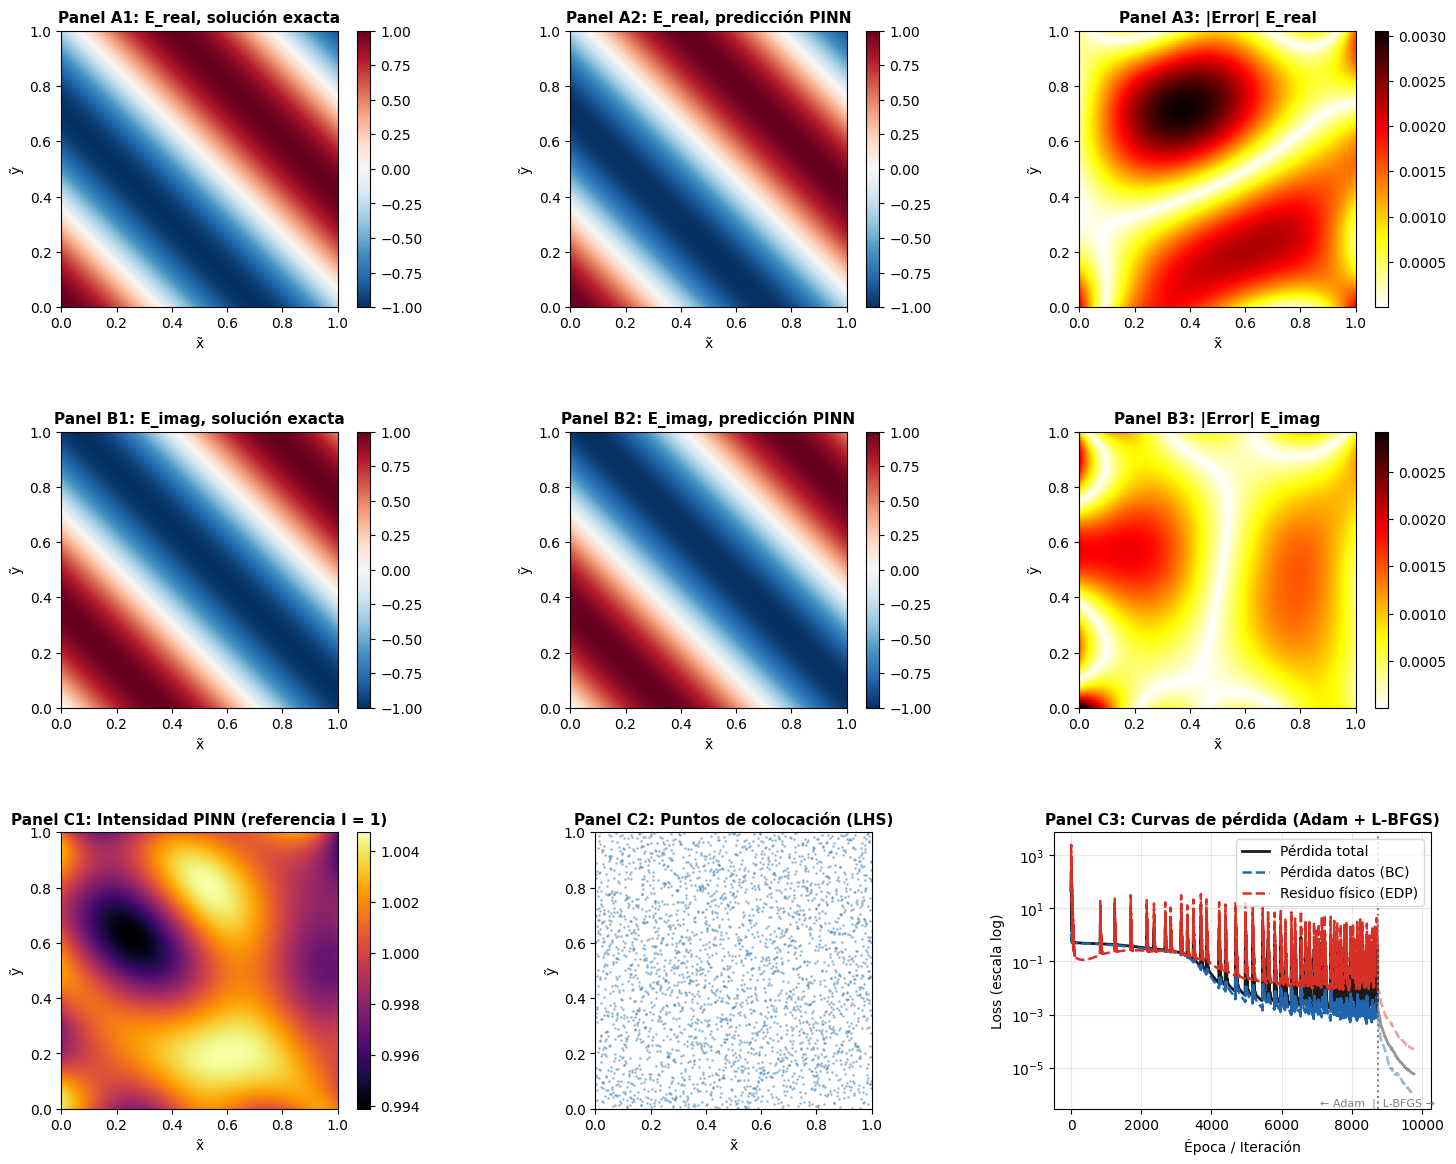

In [8]:
IMG_DIR = get_figures_dir()   # src/utils - apunta a results/figures/

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

cmap_field = 'RdBu_r'
cmap_error = 'hot_r'

COLOR_TOTAL  = '#1a1a1a'
COLOR_DATOS  = '#2166ac'
COLOR_FISICA = '#d73027'

# ── Fila 1: E_real ────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
im = ax.imshow(E_real_exact, origin='lower', extent=[0,1,0,1],
               cmap=cmap_field, vmin=-1, vmax=1)
ax.set_title('Panel A1: E_real, solución exacta', fontsize=11, fontweight='bold')
ax.set_xlabel('x̃'); ax.set_ylabel('ỹ')
plt.colorbar(im, ax=ax)

ax = fig.add_subplot(gs[0, 1])
im = ax.imshow(E_real_pred, origin='lower', extent=[0,1,0,1],
               cmap=cmap_field, vmin=-1, vmax=1)
ax.set_title('Panel A2: E_real, predicción PINN', fontsize=11, fontweight='bold')
ax.set_xlabel('x̃'); ax.set_ylabel('ỹ')
plt.colorbar(im, ax=ax)

ax = fig.add_subplot(gs[0, 2])
im = ax.imshow(error_real, origin='lower', extent=[0,1,0,1], cmap=cmap_error)
ax.set_title('Panel A3: |Error| E_real', fontsize=11, fontweight='bold')
ax.set_xlabel('x̃'); ax.set_ylabel('ỹ')
plt.colorbar(im, ax=ax)

# ── Fila 2: E_imag ────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
im = ax.imshow(E_imag_exact, origin='lower', extent=[0,1,0,1],
               cmap=cmap_field, vmin=-1, vmax=1)
ax.set_title('Panel B1: E_imag, solución exacta', fontsize=11, fontweight='bold')
ax.set_xlabel('x̃'); ax.set_ylabel('ỹ')
plt.colorbar(im, ax=ax)

ax = fig.add_subplot(gs[1, 1])
im = ax.imshow(E_imag_pred, origin='lower', extent=[0,1,0,1],
               cmap=cmap_field, vmin=-1, vmax=1)
ax.set_title('Panel B2: E_imag, predicción PINN', fontsize=11, fontweight='bold')
ax.set_xlabel('x̃'); ax.set_ylabel('ỹ')
plt.colorbar(im, ax=ax)

ax = fig.add_subplot(gs[1, 2])
im = ax.imshow(error_imag, origin='lower', extent=[0,1,0,1], cmap=cmap_error)
ax.set_title('Panel B3: |Error| E_imag', fontsize=11, fontweight='bold')
ax.set_xlabel('x̃'); ax.set_ylabel('ỹ')
plt.colorbar(im, ax=ax)

# ── Fila 3: Intensidad, LHS y pérdida ─────────────────────────────────────────
ax = fig.add_subplot(gs[2, 0])
im = ax.imshow(I_pred, origin='lower', extent=[0,1,0,1], cmap='inferno')
ax.set_title('Panel C1: Intensidad PINN (referencia I = 1)', fontsize=11, fontweight='bold')
ax.set_xlabel('x̃'); ax.set_ylabel('ỹ')
plt.colorbar(im, ax=ax)

ax = fig.add_subplot(gs[2, 1])
xy_lhs_np = xy_colloc.cpu().numpy()
ax.scatter(xy_lhs_np[:, 0], xy_lhs_np[:, 1], s=1, alpha=0.4, c='steelblue')
ax.set_title('Panel C2: Puntos de colocación (LHS)', fontsize=11, fontweight='bold')
ax.set_xlabel('x̃'); ax.set_ylabel('ỹ')
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')

# ── Curvas de pérdida - leyendas simplificadas (3 entradas) ───────────────────
ax = fig.add_subplot(gs[2, 2])
ep_adam  = range(1, epoch_final + 1)
ep_lbfgs = range(epoch_final, epoch_final + len(history_lbfgs['total']))

# Raw tenue + sin leyenda
ALPHA_RAW = 0.15
ax.semilogy(ep_adam, history['total'][:epoch_final],
            color=COLOR_TOTAL,  lw=0.8, alpha=ALPHA_RAW)
ax.semilogy(ep_adam, history['data'][:epoch_final],
            color=COLOR_DATOS,  lw=0.8, alpha=ALPHA_RAW, linestyle='--')
ax.semilogy(ep_adam, history['physics'][:epoch_final],
            color=COLOR_FISICA, lw=0.8, alpha=ALPHA_RAW, linestyle='--')

# Líneas principales con leyenda
ax.semilogy(ep_adam, history['total'][:epoch_final],
            color=COLOR_TOTAL,  lw=2,   label='Pérdida total')
ax.semilogy(ep_adam, history['data'][:epoch_final],
            color=COLOR_DATOS,  lw=1.8, linestyle='--', label='Pérdida datos (BC)')
ax.semilogy(ep_adam, history['physics'][:epoch_final],
            color=COLOR_FISICA, lw=1.8, linestyle='--', label='Residuo físico (EDP)')

# L-BFGS - sin leyenda, alpha reducido
ax.semilogy(ep_lbfgs, history_lbfgs['total'],
            color=COLOR_TOTAL,  lw=2,   alpha=0.45)
ax.semilogy(ep_lbfgs, history_lbfgs['data'],
            color=COLOR_DATOS,  lw=1.8, linestyle='--', alpha=0.45)
ax.semilogy(ep_lbfgs, history_lbfgs['physics'],
            color=COLOR_FISICA, lw=1.8, linestyle='--', alpha=0.45)

# Divisoria con anotación directa
ax.axvline(x=epoch_final, color='gray', linestyle=':', lw=1.5)
ax.annotate('← Adam  |  L-BFGS →',
            xy=(epoch_final, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 1e-10),
            fontsize=8, color='gray', ha='center', va='bottom')

ax.set_title('Panel C3: Curvas de pérdida (Adam + L-BFGS)', fontsize=11, fontweight='bold')
ax.set_xlabel('Época Adam / evaluación closure L-BFGS'); ax.set_ylabel('Loss (escala log)')
ax.legend(fontsize=10, loc='upper right'); ax.grid(True, alpha=0.3)

plt.savefig(str(IMG_DIR / 'resultados_pinn_2d_normalizado.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 8.1 Análisis de error - Figura 2

Análisis estadístico del error en el dominio normalizado $[0,1]^2$ equivalente al de NB01,
extendido a las dos componentes del campo complejo.

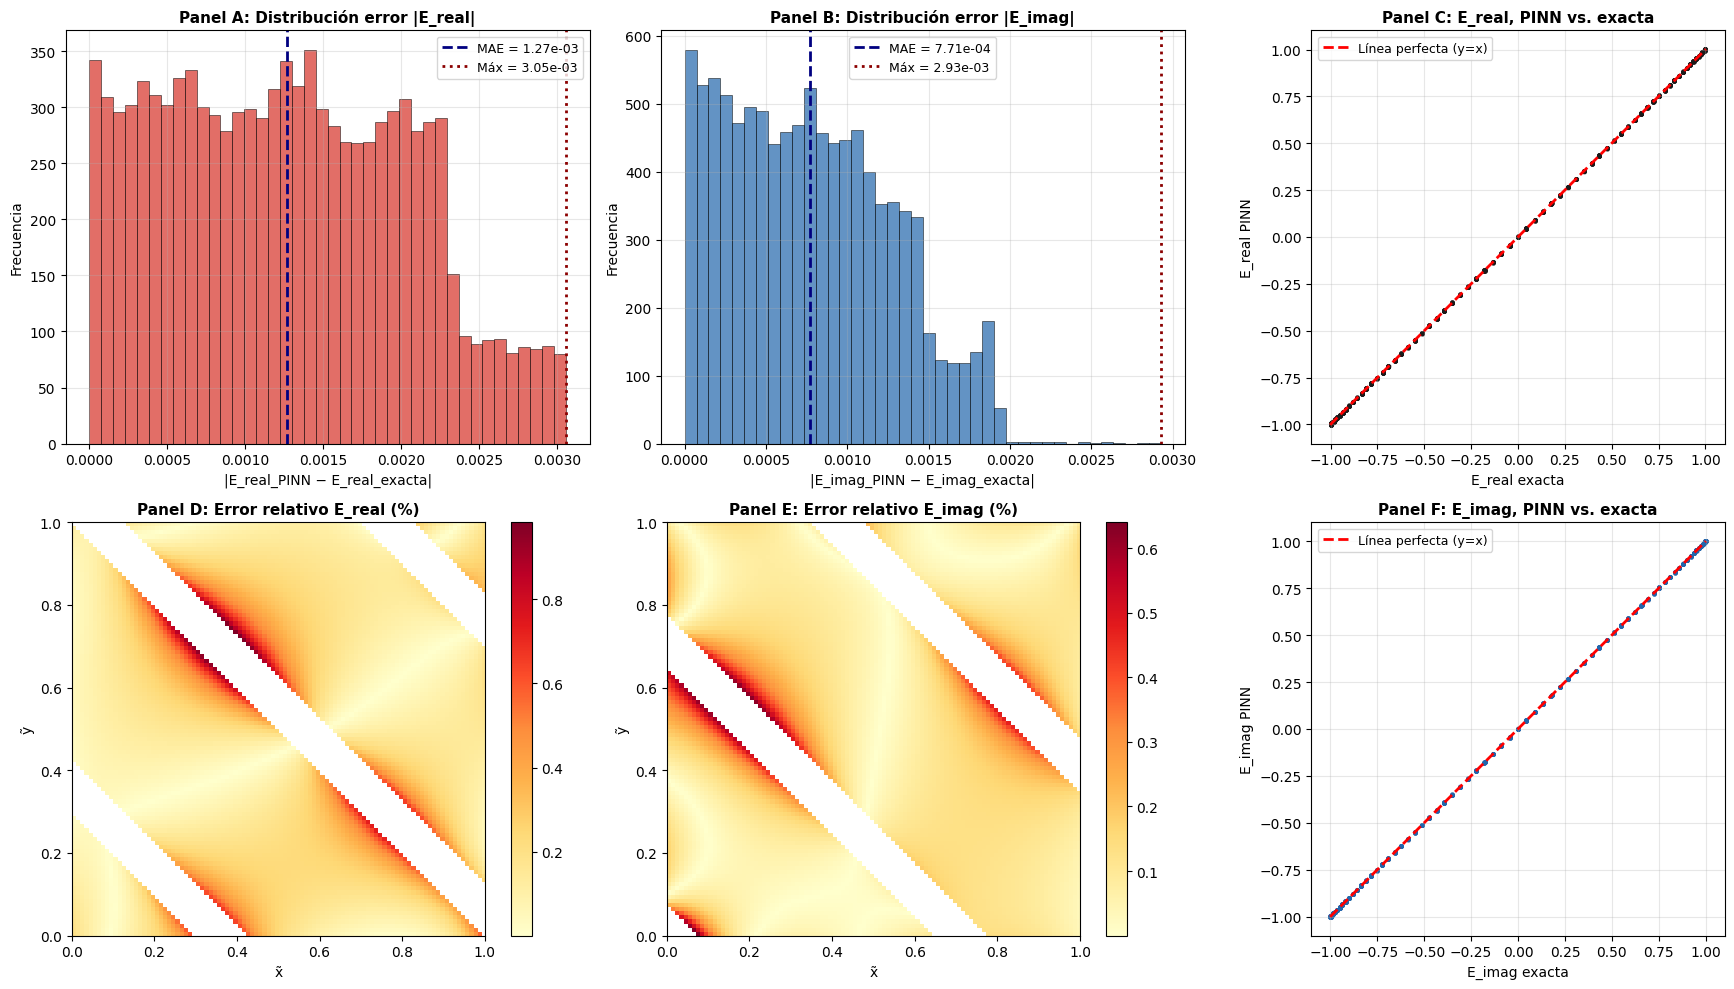

In [9]:
IMG_DIR = get_figures_dir()   # src/utils - apunta a results/figures/

fig2, axes = plt.subplots(2, 3, figsize=(18, 10))

# ── Fila 1: E_real ────────────────────────────────────────────────────────────

# Panel 1: Histograma error E_real
axes[0,0].hist(error_real.ravel(), bins=40, color='#d73027',
               alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0,0].axvline(x=mae_real, color='navy', linestyle='--',
                  linewidth=2, label=f'MAE = {mae_real:.2e}')
axes[0,0].axvline(x=error_real.max(), color='darkred', linestyle=':',
                  linewidth=2, label=f'Máx = {error_real.max():.2e}')
axes[0,0].set_title('Panel A: Distribución error |E_real|', fontsize=11, fontweight='bold')
axes[0,0].set_xlabel('|E_real_PINN − E_real_exacta|')
axes[0,0].set_ylabel('Frecuencia')
axes[0,0].legend(fontsize=9); axes[0,0].grid(True, alpha=0.3)

# Panel 2: Histograma error E_imag
axes[0,1].hist(error_imag.ravel(), bins=40, color='#2166ac',
               alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0,1].axvline(x=mae_imag, color='navy', linestyle='--',
                  linewidth=2, label=f'MAE = {mae_imag:.2e}')
axes[0,1].axvline(x=error_imag.max(), color='darkred', linestyle=':',
                  linewidth=2, label=f'Máx = {error_imag.max():.2e}')
axes[0,1].set_title('Panel B: Distribución error |E_imag|', fontsize=11, fontweight='bold')
axes[0,1].set_xlabel('|E_imag_PINN − E_imag_exacta|')
axes[0,1].set_ylabel('Frecuencia')
axes[0,1].legend(fontsize=9); axes[0,1].grid(True, alpha=0.3)

# Panel 3: Scatter E_real PINN vs Exacta
axes[0,2].scatter(E_real_exact.ravel()[::5], E_real_pred.ravel()[::5],
                  s=5, alpha=0.4, color='#1a1a1a')
min_v = min(E_real_exact.min(), E_real_pred.min())
max_v = max(E_real_exact.max(), E_real_pred.max())
axes[0,2].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2,
               label='Línea perfecta (y=x)')
axes[0,2].set_title('Panel C: E_real, PINN vs. exacta', fontsize=11, fontweight='bold')
axes[0,2].set_xlabel('E_real exacta'); axes[0,2].set_ylabel('E_real PINN')
axes[0,2].legend(fontsize=9); axes[0,2].grid(True, alpha=0.3)
axes[0,2].set_aspect('equal')

# ── Fila 2: E_imag ────────────────────────────────────────────────────────────

# Panel 4: Error relativo E_real (heatmap)
im4 = axes[1,0].imshow(np.ma.masked_invalid(np.clip(error_rel_real, 0, 5)),
                        origin='lower', extent=[0,1,0,1], cmap='YlOrRd')
axes[1,0].set_title('Panel D: Error relativo E_real (%)',
                    fontsize=11, fontweight='bold')
axes[1,0].set_xlabel('x̃'); axes[1,0].set_ylabel('ỹ')
plt.colorbar(im4, ax=axes[1,0])

# Panel 5: Error relativo E_imag (heatmap)
im5 = axes[1,1].imshow(np.ma.masked_invalid(np.clip(error_rel_imag, 0, 5)),
                        origin='lower', extent=[0,1,0,1], cmap='YlOrRd')
axes[1,1].set_title('Panel E: Error relativo E_imag (%)',
                    fontsize=11, fontweight='bold')
axes[1,1].set_xlabel('x̃'); axes[1,1].set_ylabel('ỹ')
plt.colorbar(im5, ax=axes[1,1])

# Panel 6: Scatter E_imag PINN vs Exacta
axes[1,2].scatter(E_imag_exact.ravel()[::5], E_imag_pred.ravel()[::5],
                  s=5, alpha=0.4, color='#2166ac')
min_v = min(E_imag_exact.min(), E_imag_pred.min())
max_v = max(E_imag_exact.max(), E_imag_pred.max())
axes[1,2].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2,
               label='Línea perfecta (y=x)')
axes[1,2].set_title('Panel F: E_imag, PINN vs. exacta', fontsize=11, fontweight='bold')
axes[1,2].set_xlabel('E_imag exacta'); axes[1,2].set_ylabel('E_imag PINN')
axes[1,2].legend(fontsize=9); axes[1,2].grid(True, alpha=0.3)
axes[1,2].set_aspect('equal')

plt.tight_layout()
plt.savefig(str(IMG_DIR / 'metricas_adicionales_2d_normalizado.png'), dpi=150, bbox_inches='tight')
plt.show()

In [10]:
print('=' * 58)
print('RESUMEN DE RESULTADOS - PINN 2D SIREN')
print('=' * 58)
print(f'  Semilla usada         : {CONFIG["seed"]}')
print(f'  k̃                     : 2π = {k:.4f}')
print(f'  k̃_x = k̃_y             : {k_x:.4f}')
print()
print('Métricas de precisión:')
print(f'  {"Métrica":<22} {"E_real":>10} {"E_imag":>10}')
print(f'  {"-"*44}')
print(f'  {"Error L2 (%)":<22} {l2_real*100:>10.3f} {l2_imag*100:>10.3f}')
print(f'  {"MSE":<22} {mse_real:>10.2e} {mse_imag:>10.2e}')
print(f'  {"RMSE":<22} {rmse_real:>10.2e} {rmse_imag:>10.2e}')
print(f'  {"MAE":<22} {mae_real:>10.2e} {mae_imag:>10.2e}')
print(f'  {"Error máximo":<22} {error_real.max():>10.2e} {error_imag.max():>10.2e}')
print(f'  {"R²":<22} {r2_real:>10.6f} {r2_imag:>10.6f}')
print(f'  {"Correlación Pearson":<22} {corr_real:>10.6f} {corr_imag:>10.6f}')
print(f'  {"Promedio L2 componentes*":<28} {l2_component_mean*100:>10.3f}%')
print(f'  {"L2 complejo conjunto":<28} {l2_complex*100:>10.3f}%')
print(f'  {"L2 de intensidad":<28} {l2_intensity*100:>10.3f}%')
print(f'  {"RMSE fase (rad)":<28} {phase_rmse:>10.3e}')
print(f'  {"Residuo RMS complejo relativo":<35} {residual_rel_complex:>10.3e}')
print('  * Métrica histórica usada para reportar 0.171%.')
print(f'  {"Umbral tesis (L2 complejo)":<28} {"< 5%":>10}')
print(f'  {"Estado":<22} {"CUMPLE" if cumple else "AUN NO CUMPLE":>10}')
print()
print('Entrenamiento:')
print(f'  Épocas Adam           : {epoch_final} / {CONFIG["n_epochs"]}')
print(f'  Early stopping        : por paciencia ({CONFIG["patience"]} épocas)')
print(f'  Mejor L_total (Adam)  : {best_loss:.3e}')
print(f'  Tiempo Adam           : {tiempo_adam:.1f} s')
print(f'  Máximo iteraciones L-BFGS : {CONFIG["lbfgs_max_iter"]}')
print(f'  Evaluaciones de closure   : {closure_eval_count[0]}')
print(f'  Tiempo L-BFGS         : {tiempo_lbfgs:.1f} s')
print(f'  Tiempo TOTAL          : {tiempo_adam + tiempo_lbfgs:.1f} s')
print()
print('Hiperparámetros:')
print(f'  hidden_dim            = {CONFIG["hidden_dim"]}')
print(f'  num_layers            = {CONFIG["num_layers"]}')
print(f'  omega_0               = {CONFIG["omega_0"]}')
print(f'  n_epochs (máx)        = {CONFIG["n_epochs"]}')
print(f'  lr                    = {CONFIG["lr"]}')
print(f'  physics_weight (w_f)  = {CONFIG["physics_weight"]}')
print(f'  N_colloc (LHS)        = {CONFIG["N_colloc"]}')
print(f'  frontera (por borde)  = {CONFIG["N_boundary_per_edge"]}  → {4*CONFIG["N_boundary_per_edge"]} filas')
print(f'  patience              = {CONFIG["patience"]}')
print(f'  lbfgs_max_iter        = {CONFIG["lbfgs_max_iter"]}')
print(f'  lbfgs_history         = {CONFIG["lbfgs_history"]}')
print(f'  seed                  = {CONFIG["seed"]}')
print()
lam = CONFIG['lambda_laser']

L   = CONFIG['L']
print('Láser simulado:')
print(f'  lambda_laser          : {lam * 1e9:.0f} nm')
print(f'  k real equivalente    : {2 * np.pi / lam:.3e} m⁻¹')
print(f'  Dominio simulado      : {L}×{L} λ  →  {L * lam * 1e6:.4f} × {L * lam * 1e6:.4f} μm²')

RESUMEN DE RESULTADOS - PINN 2D SIREN
  Semilla usada         : 42
  k̃                     : 2π = 6.2832
  k̃_x = k̃_y             : 4.4429

Métricas de precisión:
  Métrica                    E_real     E_imag
  --------------------------------------------
  Error L2 (%)                0.214      0.127
  MSE                      2.20e-06   8.43e-07
  RMSE                     1.48e-03   9.18e-04
  MAE                      1.27e-03   7.71e-04
  Error máximo             3.05e-03   2.93e-03
  R²                       0.999995   0.999998
  Correlación Pearson      0.999998   0.999999
  Promedio L2 componentes*          0.171%
  L2 complejo conjunto              0.174%
  L2 de intensidad                  0.248%
  RMSE fase (rad)               1.228e-03
  Residuo RMS complejo relativo        1.963e-04
  * Métrica histórica usada para reportar 0.171%.
  Umbral tesis (L2 complejo)         < 5%
  Estado                     CUMPLE

Entrenamiento:
  Épocas Adam           : 8737 / 15000
  Early s

---
## Interpretación y siguiente paso

Este notebook valida que la PINN-SIREN representa una solución compleja de Helmholtz 2D normalizada para un caso analítico controlado. El promedio aritmético histórico de los errores por componente es 0.171% (0.214% real y 0.127% imaginario), por debajo del umbral de 5%. Al volver a ejecutar esta copia también se calcularán la norma L2 conjunta del campo complejo, el error de intensidad, el error circular de fase y el residuo de Helmholtz sobre la malla de evaluación.

### Qué demuestra y qué no demuestra

| Sí demuestra | Todavía no demuestra |
|---|---|
| Resolución de Helmholtz homogénea en 2D cartesiano | Formación de speckle |
| Representación de un campo complejo con dos salidas | Propagación entre planos a distintas distancias |
| Compatibilidad entre frontera, solución analítica y residuo físico | Aceleración frente a FEM u otro método numérico |
| Funcionamiento de SIREN en una onda plana conocida | Generalización a fronteras aleatorias o espectros multiescala |

La intensidad de referencia aquí es $I_{\mathrm{ref}}=1$; no contiene los máximos y mínimos aleatorios característicos del speckle. Por ello, NB03 debe introducir un campo inicial aleatorio y compararlo con una referencia de propagación independiente, como el método del espectro angular.

### Relación con los archivos del proyecto

| Archivo | Papel |
|---|---|
| `01_validacion_helmholtz_1d_normalizada.ipynb` | Validación didáctica normalizada en 1D |
| `02_validacion_helmholtz_2d_normalizada.ipynb` | Validación analítica normalizada en 2D |
| `03_simulacion_speckle_2d_pinn_siren_modal.ipynb` | Simulación y validación del caso speckle |

> **Nota sobre reutilización:** el checkpoint de esta copia sirve para reproducir y evaluar esta misma arquitectura analítica. No constituye por sí mismo un modelo validado para NB03; una transferencia directa a speckle debe justificarse y evaluarse porque cambia el contenido espectral del campo.

In [11]:
# ── Exportar modelo entrenado ─────────────────────────────────────────────────
# Nombre independiente para no sobrescribir el checkpoint del NB02 original.
# Solo es compatible con esta misma arquitectura y configuración analítica.
model_path = save_model(
    model_2d,
    'nb02_helmholtz2d_normalizado_gpu',
    notebook_dir=PROJECT_ROOT,
)
assert Path(model_path).resolve().is_relative_to(PROJECT_ROOT.resolve())
model_path


Modelo guardado en: C:\roberto\Tesis_Maestria - codex\results\models\nb02_helmholtz2d_normalizado_gpu.pt


'C:\\roberto\\Tesis_Maestria - codex\\results\\models\\nb02_helmholtz2d_normalizado_gpu.pt'

---
## 9. Extensión: validación multidireccional de la onda plana

La solución compleja usada originalmente contiene coseno y seno como partes real e imaginaria, pero sólo comprueba una dirección del vector de onda. Para evaluar robustez direccional se consideran

$$E_{s_x,s_y}(\widetilde{x},\widetilde{y})=\exp\left[i\left(s_x\widetilde{k}_x\widetilde{x}+s_y\widetilde{k}_y\widetilde{y}\right)\right],\qquad s_x,s_y\in\{-1,+1\},$$

con $|\widetilde{k}_x|=|\widetilde{k}_y|=2\pi/\sqrt{2}$. En los cuatro casos se conserva exactamente $\widetilde{k}_x^2+\widetilde{k}_y^2=(2\pi)^2$, por lo que todos satisfacen Helmholtz.

El caso $(+,+)$ es la corrida canónica ya validada de NB02. Los otros tres casos se entrenaron de manera independiente desde la misma semilla, con la misma SIREN 5×128, 3,000 puntos LHS, 1,200 filas de frontera, Adam y L-BFGS.

| Dirección | Interpretación | L2 real | L2 imaginario | L2 complejo | L2 intensidad | Residuo relativo | Estado |
|---|---|---:|---:|---:|---:|---:|---|
| $(+k_x,+k_y)$ | $45^\circ$ | 0.2141% | 0.1273% | **0.1744%** | 0.2476% | 1.963e-4 | Cumple |
| $(+k_x,-k_y)$ | $-45^\circ$ | 0.2276% | 0.0960% | **0.1775%** | 0.2468% | 2.594e-4 | Cumple |
| $(-k_x,+k_y)$ | $135^\circ$ | 0.0759% | 0.1649% | **0.1264%** | 0.1771% | 2.504e-4 | Cumple |
| $(-k_x,-k_y)$ | $-135^\circ$ | 0.1865% | 0.0972% | **0.1470%** | 0.2215% | 2.336e-4 | Cumple |

**Resultado conjunto:** 4/4 direcciones aceptadas; L2 complejo medio = **0.1563%** y peor caso = **0.1775%**, ambos muy por debajo del criterio de 5%.

![Comparación multidireccional de NB02](../results/figures/nb02_multidirectional_validation.png)


In [12]:
# Lectura verificable de los resultados multidireccionales ya calculados.
from pathlib import Path
import json

summary_path = PROJECT_ROOT / 'results' / 'nb02_multidirectional' / 'validation_summary.json'
direction_summary = json.loads(summary_path.read_text(encoding='utf-8'))

for key, result in direction_summary['directions'].items():
    metrics = result['metrics']
    print(f"{key}: {result['label']:<19} | L2 complejo={metrics['l2_complex_percent']:.6f}% | "
          f"residuo relativo={metrics['residual_relative_complex']:.3e} | "
          f"{'CUMPLE' if metrics['accepted_l2_below_5_percent'] else 'NO CUMPLE'}")

aggregate = direction_summary['aggregate']
assert aggregate['all_directions_accepted'], 'Alguna dirección no cumple L2 < 5%'
print(f"\nResultado: {aggregate['accepted_count']}/{aggregate['total_count']} direcciones aceptadas")
print(f"L2 complejo medio: {aggregate['mean_l2_complex_percent']:.6f}%")
print(f"Peor L2 complejo : {aggregate['worst_l2_complex_percent']:.6f}%")


pp: (+kx,+ky), 45°     | L2 complejo=0.174386% | residuo relativo=1.963e-04 | CUMPLE
pm: (+kx,-ky), -45°    | L2 complejo=0.177516% | residuo relativo=2.594e-04 | CUMPLE
mp: (-kx,+ky), 135°    | L2 complejo=0.126357% | residuo relativo=2.504e-04 | CUMPLE
mm: (-kx,-ky), -135°   | L2 complejo=0.146955% | residuo relativo=2.336e-04 | CUMPLE

Resultado: 4/4 direcciones aceptadas
L2 complejo medio: 0.156303%
Peor L2 complejo : 0.177516%


### Reproducibilidad y alcance

La ejecución completa se reproduce con el archivo scripts/experiments/nb02_multidirectional_validation.py. El script reutiliza únicamente el checkpoint canónico para $(+,+)$ y entrena desde cero las otras tres redes. Guarda un JSON por dirección, arreglos de evaluación, checkpoints, la figura comparativa y el resumen canónico results/nb02_multidirectional/validation_summary.json.

> **Interpretación correcta:** esta extensión demuestra que la configuración de NB02 no está restringida a una única orientación diagonal. Para los valores fijos $|\widetilde{k}_x|=|\widetilde{k}_y|=\widetilde{k}/\sqrt{2}$, las cuatro ondas complejas forman una base equivalente a las cuatro combinaciones reales seno--coseno demostradas en la sección siguiente. No constituyen una base completa de todas las soluciones de Helmholtz 2D cuando también varía la dirección del vector de onda. Tampoco demuestran todavía formación de speckle; esa función corresponde a NB03.


---
## 10. Base real separable exacta y equivalencia con la validación compleja

Esta sección hace explícita la continuidad matemática con NB01. No introduce una formulación modal ni modifica la arquitectura directa: la PINN sigue recibiendo $(\widetilde{x},\widetilde{y})$ y devolviendo el campo en ese punto.

### 10.1 Separación de variables sin omitir pasos

Partimos de

$$E_{\widetilde{x}\widetilde{x}}+E_{\widetilde{y}\widetilde{y}}+\widetilde{k}^{2}E=0$$

y proponemos una solución separable $E(\widetilde{x},\widetilde{y})=X(\widetilde{x})Y(\widetilde{y})$. Entonces

$$X''Y+XY''+\widetilde{k}^{2}XY=0.$$

En los puntos donde $XY\neq0$, dividir entre $XY$ produce

$$\frac{X''}{X}+\frac{Y''}{Y}+\widetilde{k}^{2}=0.$$

El primer cociente depende sólo de $\widetilde{x}$ y el segundo sólo de $\widetilde{y}$; por tanto, ambos deben ser constantes. Escribimos

$$X''+\widetilde{k}_x^2X=0,\qquad Y''+\widetilde{k}_y^2Y=0,\qquad \widetilde{k}_x^2+\widetilde{k}_y^2=\widetilde{k}^2.$$

Las soluciones unidimensionales son

$$X=A\cos(\widetilde{k}_x\widetilde{x})+B\sin(\widetilde{k}_x\widetilde{x}),\qquad Y=C\cos(\widetilde{k}_y\widetilde{y})+D\sin(\widetilde{k}_y\widetilde{y}).$$

Al multiplicar aparecen las cuatro soluciones exactas

$$\phi_1=\cos(\widetilde{k}_x\widetilde{x})\cos(\widetilde{k}_y\widetilde{y}),\qquad \phi_2=\cos(\widetilde{k}_x\widetilde{x})\sin(\widetilde{k}_y\widetilde{y}),$$

$$\phi_3=\sin(\widetilde{k}_x\widetilde{x})\cos(\widetilde{k}_y\widetilde{y}),\qquad \phi_4=\sin(\widetilde{k}_x\widetilde{x})\sin(\widetilde{k}_y\widetilde{y}).$$

Para cada una, $\partial_{\widetilde{x}}^2\phi_j=-\widetilde{k}_x^2\phi_j$ y $\partial_{\widetilde{y}}^2\phi_j=-\widetilde{k}_y^2\phi_j$. En consecuencia,

$$\nabla^2\phi_j+\widetilde{k}^2\phi_j=(-\widetilde{k}_x^2-\widetilde{k}_y^2+\widetilde{k}^2)\phi_j=0.$$

### 10.2 Independencia lineal

Las parejas $\{\cos(\widetilde{k}_x\widetilde{x}),\sin(\widetilde{k}_x\widetilde{x})\}$ y $\{\cos(\widetilde{k}_y\widetilde{y}),\sin(\widetilde{k}_y\widetilde{y})\}$ son linealmente independientes. El producto tensorial de dos conjuntos independientes también es independiente; por ello, $\{\phi_1,\phi_2,\phi_3,\phi_4\}$ es una base del subespacio separable asociado con los valores fijos $(\widetilde{k}_x,\widetilde{k}_y)$. Esto no afirma completitud respecto de todos los ángulos posibles.

### 10.3 Equivalencia con las cuatro ondas ya entrenadas

Definimos $F_{s_xs_y}=\exp[i(s_x\widetilde{k}_x\widetilde{x}+s_y\widetilde{k}_y\widetilde{y})]$. Aplicando Euler se obtiene

$$\phi_1=\frac{F_{++}+F_{+-}+F_{-+}+F_{--}}{4},$$

$$\phi_2=\frac{F_{++}-F_{+-}+F_{-+}-F_{--}}{4i},\qquad \phi_3=\frac{F_{++}+F_{+-}-F_{-+}-F_{--}}{4i},$$

$$\phi_4=\frac{-F_{++}+F_{+-}+F_{-+}-F_{--}}{4}.$$

La transformación es invertible. Por tanto, las cuatro ondas complejas validadas numéricamente y las cuatro soluciones reales separables generan exactamente el mismo subespacio para $|\widetilde{k}_x|=|\widetilde{k}_y|=\widetilde{k}/\sqrt{2}$. No son las mismas funciones término a término: cada función de una familia se obtiene como combinación lineal de la otra. Las primeras conservan la interpretación de propagación; las segundas hacen explícita la estructura matemática heredada de NB01.

> **Conclusión matemática de NB02:** se comprobó computacionalmente una base compleja de cuatro ondas planas direccionales y se demostró su equivalencia con la base real separable $\{\cos\cos,\cos\sin,\sin\cos,\sin\sin\}$ para el par de números de onda seleccionado.


In [13]:
# Verificación reproducible de las identidades analíticas de la sección 10.
# Esta celda no entrena una red ni usa una formulación modal.
basis_grid = np.linspace(0.0, 1.0, 121)
BX, BY = np.meshgrid(basis_grid, basis_grid, indexing='xy')
ax = k_x * BX
ay = k_y * BY

phi = {
    'cos-cos': np.cos(ax) * np.cos(ay),
    'cos-sin': np.cos(ax) * np.sin(ay),
    'sin-cos': np.sin(ax) * np.cos(ay),
    'sin-sin': np.sin(ax) * np.sin(ay),
}

Fpp = np.exp(1j * ( ax + ay))
Fpm = np.exp(1j * ( ax - ay))
Fmp = np.exp(1j * (-ax + ay))
Fmm = np.exp(1j * (-ax - ay))

phi_from_complex = {
    'cos-cos': ( Fpp + Fpm + Fmp + Fmm) / 4,
    'cos-sin': ( Fpp - Fpm + Fmp - Fmm) / (4j),
    'sin-cos': ( Fpp + Fpm - Fmp - Fmm) / (4j),
    'sin-sin': (-Fpp + Fpm + Fmp - Fmm) / 4,
}

print('BASE REAL SEPARABLE EXACTA DE NB02')
print('-' * 72)
for name in phi:
    # La identidad diferencial es analítica: phi_xx=-kx² phi y phi_yy=-ky² phi.
    residual_exact = (-k_x**2 - k_y**2 + k**2) * phi[name]
    equivalence_error = np.max(np.abs(phi[name] - phi_from_complex[name]))
    print(f'{name:>9}: máximo |R_H|={np.max(np.abs(residual_exact)):.3e} | ' 
          f'error de equivalencia={equivalence_error:.3e}')

Phi = np.column_stack([value.ravel() for value in phi.values()])
rank = np.linalg.matrix_rank(Phi)
gram = (Phi.T @ Phi) / Phi.shape[0]
print(f'\nRango numérico de las cuatro funciones muestreadas: {rank}/4')
print(f'Menor autovalor de la matriz de Gram: {np.linalg.eigvalsh(gram).min():.6e}')
assert rank == 4
assert all(np.max(np.abs(phi[name] - phi_from_complex[name])) < 1e-12 for name in phi)
print('Resultado: identidades de Helmholtz, equivalencia e independencia verificadas.')


BASE REAL SEPARABLE EXACTA DE NB02
------------------------------------------------------------------------
  cos-cos: máximo |R_H|=0.000e+00 | error de equivalencia=4.996e-16
  cos-sin: máximo |R_H|=0.000e+00 | error de equivalencia=3.342e-16
  sin-cos: máximo |R_H|=0.000e+00 | error de equivalencia=3.342e-16
  sin-sin: máximo |R_H|=0.000e+00 | error de equivalencia=5.551e-16

Rango numérico de las cuatro funciones muestreadas: 4/4
Menor autovalor de la matriz de Gram: 1.531691e-01
Resultado: identidades de Helmholtz, equivalencia e independencia verificadas.


### Alcance de esta ampliación

La demostración anterior fortalece la interpretación matemática sin añadir cuatro entrenamientos redundantes. Los errores L2 siguen correspondiendo a las cuatro ondas complejas entrenadas de manera independiente. Las funciones producto se verifican exactamente mediante la ecuación y mediante la transformación de Euler. Si en el futuro se desean errores L2 separados para cada $\phi_j$, será necesario entrenar cuatro problemas de frontera adicionales o reconstruirlos explícitamente a partir de las cuatro predicciones complejas almacenadas.
